In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/StressLevelDataset.csv")

In [3]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [4]:
df.isnull().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [5]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.00000,1000.00000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,11.056000,17.87000,0.494000,12.511000,2.49500,2.16600,2.674000,2.752000,2.64000,2.51700,...,2.770000,2.780000,2.629000,2.661000,2.652000,1.902000,2.724000,2.772000,2.608000,0.993000
std,6.084232,8.93952,0.500214,7.678466,1.39783,0.83495,1.536257,1.389398,1.32066,1.11398,...,1.436372,1.401986,1.307313,1.371846,1.528146,1.044743,1.425432,1.411385,1.528618,0.818304
min,0.000000,0.00000,0.000000,0.000000,0.00000,1.00000,0.000000,0.000000,0.00000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.00000,0.000000,7.000000,1.00000,1.00000,1.000000,2.000000,2.00000,2.00000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.00000,0.000000,12.000000,3.00000,2.00000,3.000000,2.500000,3.00000,2.00000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000
75%,16.000000,26.00000,1.000000,19.000000,3.00000,3.00000,4.000000,4.000000,3.00000,3.00000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.00000,1.000000,27.000000,5.00000,3.00000,5.000000,5.000000,5.00000,5.00000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [6]:
df["stress_level"].value_counts()

stress_level
0    338
1    331
2    331
Name: count, dtype: int64

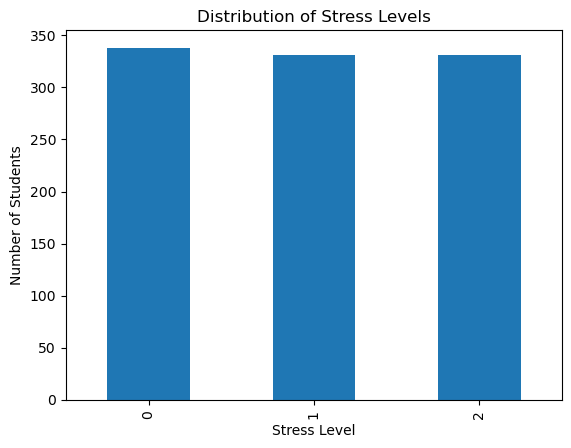

In [7]:
import matplotlib.pyplot as plt

df["stress_level"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")
plt.show()

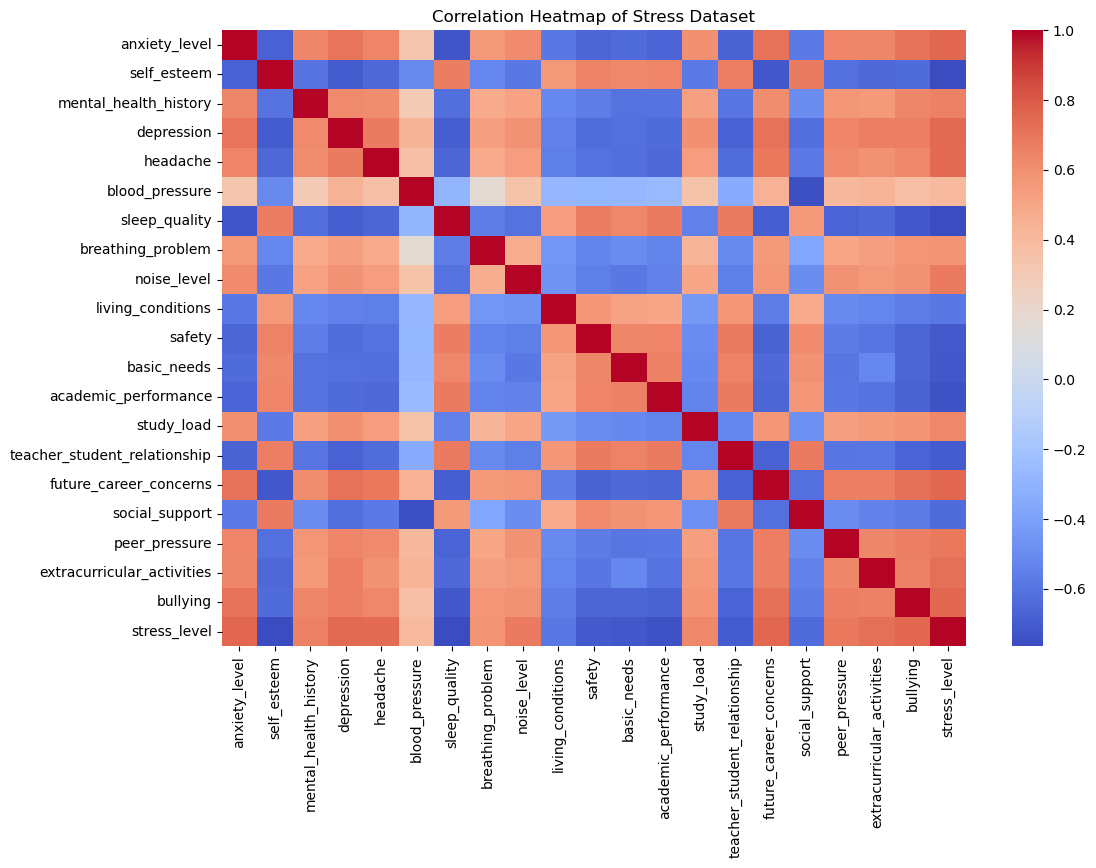

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap of Stress Dataset")
plt.show()

In [9]:
corr_with_stress = df.corr()["stress_level"].sort_values(ascending=False)

print(corr_with_stress)

stress_level                    1.000000
future_career_concerns          0.756913
bullying                        0.753232
anxiety_level                   0.753029
depression                      0.751243
headache                        0.739005
extracurricular_activities      0.722321
peer_pressure                   0.695177
noise_level                     0.679387
mental_health_history           0.661400
study_load                      0.631980
breathing_problem               0.584836
blood_pressure                  0.395807
living_conditions              -0.582412
social_support                 -0.637759
teacher_student_relationship   -0.701202
safety                         -0.709439
basic_needs                    -0.721002
academic_performance           -0.737752
self_esteem                    -0.760669
sleep_quality                  -0.764637
Name: stress_level, dtype: float64


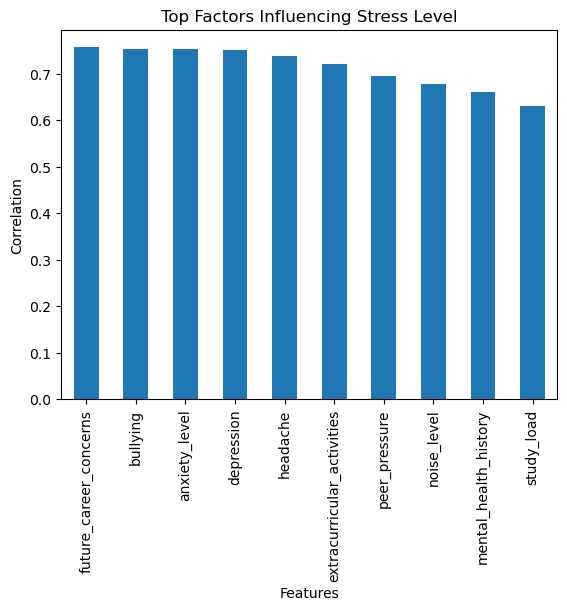

In [10]:
import matplotlib.pyplot as plt

corr_with_stress.drop("stress_level").head(10).plot(kind="bar")

plt.title("Top Factors Influencing Stress Level")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.show()

In [11]:
X = df.drop("stress_level", axis=1)
y = df["stress_level"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    }

lr_results = evaluate_model(y_test, y_pred_lr)
dt_results = evaluate_model(y_test, y_pred_dt)
rf_results = evaluate_model(y_test, y_pred_rf)

print("Logistic Regression:", lr_results)
print("Decision Tree:", dt_results)
print("Random Forest:", rf_results)

Logistic Regression: {'Accuracy': 0.915, 'Precision': 0.9156425063284174, 'Recall': 0.915, 'F1 Score': 0.9149349421130302}
Decision Tree: {'Accuracy': 0.89, 'Precision': 0.8911059143996581, 'Recall': 0.89, 'F1 Score': 0.8901556713212829}
Random Forest: {'Accuracy': 0.885, 'Precision': 0.8850198412698412, 'Recall': 0.885, 'F1 Score': 0.884972389380531}


In [18]:
import pandas as pd

results_df = pd.DataFrame({
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results
}).T

print(results_df)

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.915   0.915643   0.915  0.914935
Decision Tree           0.890   0.891106   0.890  0.890156
Random Forest           0.885   0.885020   0.885  0.884972


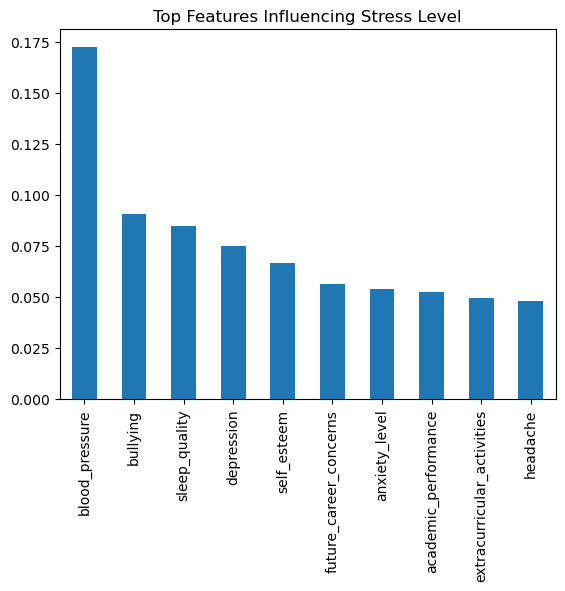

In [19]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Features Influencing Stress Level")
plt.show()

In [20]:
import pandas as pd

df_dep = pd.read_csv("../data/processed/StressLevelDataset.csv")

In [21]:
df_dep.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


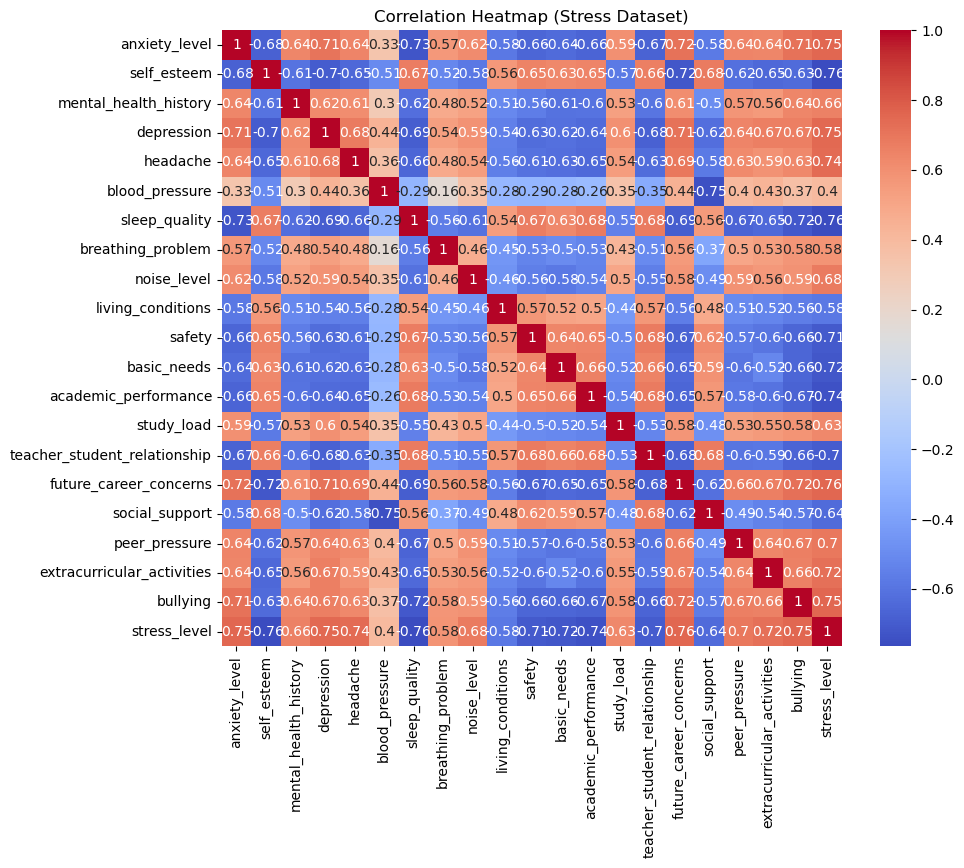

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_dep.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap (Stress Dataset)")
plt.show()

In [23]:
df_dep.columns

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='str')

In [24]:
X = df_dep.drop("stress_level", axis=1)
y = df_dep["stress_level"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = rf.predict(X_test)

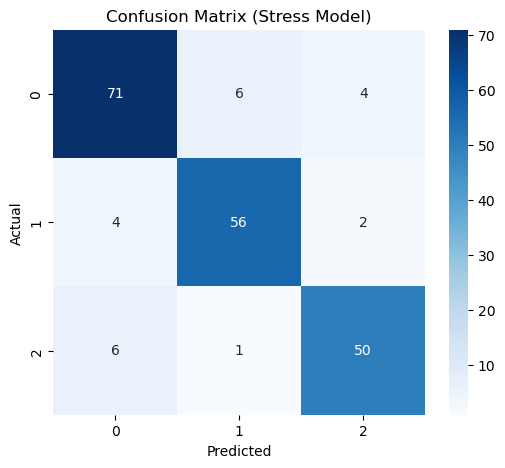

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (Stress Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
# Generate predictions
y_pred = rf.predict(X_test)

In [30]:
# Create comparison table
results_table = X_test.copy()

In [31]:
# Add actual values
results_table['Actual'] = y_test.values

In [ ]:
results_table = X_test.copy()

results_table['Actual'] = y_test.values
results_table['Predicted'] = y_pred

results_table['Status'] = results_table.apply(
    lambda row: 'Correct' if row['Actual'] == row['Predicted'] else 'Wrong',
    axis=1
)

results_table = results_table.reset_index()

results_table.head(10)